# 1. Importing libraries

In [1]:
import pandas as pd
import os
import shapely
from shapely.ops import unary_union
shapely.ops.cascaded_union = unary_union
import geopandas
from keplergl import KeplerGl
from pyproj import CRS
import numpy as np
from matplotlib import pyplot as plt
import ipywidgets

# 2. Loading data

In [2]:
df = pd.read_csv('NY_data_1.csv', low_memory=False, encoding='latin1', index_col = 0)

In [3]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,255},{920,789}}\t#/;R_klmnoÃÂ,date,avgTemp
0,9D0DC440CB40CF8E,electric_bike,2022-08-27 13:56:47.728,2022-08-27 14:02:56.651,Flatbush Ave & Ocean Ave,3704.04,3 St & Prospect Park West,3865.05,40.663657,-73.963014,40.668132,-73.973638,casual,NaN,NaN,NaN,2022-08-27,27.8
1,2214991DFBE5C4D7,electric_bike,2022-08-20 10:37:02.756,2022-08-20 10:45:56.631,Forsyth St\t& Grand St,5382.07,E 11 St & 1 Ave,5746.14,40.717798,-73.993161,40.729538,-73.984267,casual,NaN,NaN,NaN,2022-08-20,27.9
2,20C5D469563B6337,classic_bike,2022-08-31 18:55:03.051,2022-08-31 19:03:37.344,Perry St & Bleecker St,5922.07,Grand St & Greene St,5500.02,40.735354,-74.004831,40.721700,-74.002381,member,NaN,NaN,NaN,2022-08-31,25.6
3,3E8791885BC189D1,classic_bike,2022-08-02 08:05:00.250,2022-08-02 08:16:52.063,FDR Drive & E 35 St,6230.04,Grand Army Plaza & Central Park S,6839.10,40.744219,-73.971212,40.764397,-73.973715,member,NaN,NaN,NaN,2022-08-02,26.4
4,8DBCBF98885106CB,electric_bike,2022-08-25 15:44:48.386,2022-08-25 15:55:39.691,E 40 St & 5 Ave,6474.11,Ave A & E 14 St,5779.11,40.752052,-73.982115,40.730311,-73.980472,member,NaN,NaN,NaN,2022-08-25,28.1


# 3. Data preprocessing

In [4]:
# Create a value column and group by start and end station 

df['value'] = 1
df_group = df.groupby(['start_station_name', 'end_station_name', 'start_lat', 'start_lng', 'end_lat', 'end_lng'])['value'].count().reset_index()

In [5]:
df_group

,start_station_name,end_station_name,start_lat,start_lng,end_lat,end_lng,value
0,1 Ave & E 110 St,1 Ave & E 110 St,40.792062,-73.937756,40.792327,-73.938300,1
1,1 Ave & E 110 St,1 Ave & E 110 St,40.792078,-73.937701,40.792327,-73.938300,1
2,1 Ave & E 110 St,1 Ave & E 110 St,40.792144,-73.937845,40.792327,-73.938300,1
3,1 Ave & E 110 St,1 Ave & E 110 St,40.792199,-73.937879,40.792327,-73.938300,1
4,1 Ave & E 110 St,1 Ave & E 110 St,40.792215,-73.938039,40.792327,-73.938300,1
...,...,...,...,...,...,...,...
5004650,Yankee Ferry Terminal,Yankee Ferry Terminal,40.687181,-74.016553,40.687066,-74.016756,1
5004651,Yankee Ferry Terminal,Yankee Ferry Terminal,40.687197,-74.016486,40.687066,-74.016756,1
5004652,Yankee Ferry Terminal,Yankee Ferry Terminal,40.687216,-74.016586,40.687066,-74.016756,1
5004653,Yankee Ferry Terminal,Yankee Ferry Terminal,40.687234,-74.016551,40.687066,-74.016756,1


In [6]:
print(df_group['value'].sum())
print(df.shape)

29768714
(29838821, 19)


[]

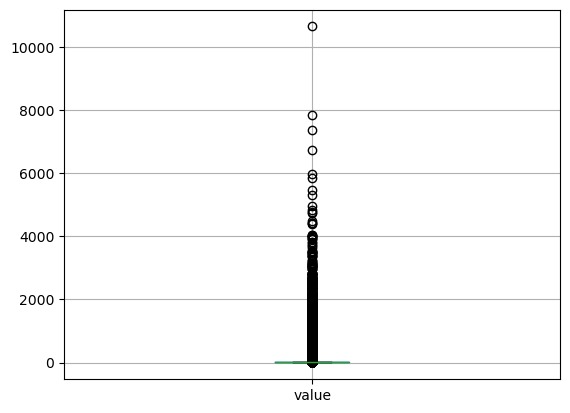

In [7]:
b_plot = df_group.boxplot(column = 'value')
b_plot.plot()

In [8]:
df_group['value'].sort_index().value_counts()

value
1       4316586
2        129965
3         74389
4         50919
5         37982
         ...   
3808          1
1399          1
1793          1
2036          1
4846          1
Name: count, Length: 1710, dtype: int64

In [9]:
df_group.rename(columns = {'value': 'trips'}, inplace = True)

In [14]:
limited_df = df_group.loc[((df_group['trips']>100))]

In [17]:
limited_df.head()

,start_station_name,end_station_name,start_lat,start_lng,end_lat,end_lng,trips
25,1 Ave & E 110 St,1 Ave & E 110 St,40.792327,-73.9383,40.792327,-73.938300,673
137,1 Ave & E 110 St,1 Ave & E 94 St,40.792327,-73.9383,40.781721,-73.945940,210
179,1 Ave & E 110 St,2 Ave & E 104 St,40.792327,-73.9383,40.789211,-73.943708,224
239,1 Ave & E 110 St,2 Ave & E 125 St,40.792327,-73.9383,40.802554,-73.933509,162
264,1 Ave & E 110 St,2 Ave & E 29 St,40.792327,-73.9383,40.741724,-73.978093,103


In [24]:
limited_df.describe()

,start_lat,start_lng,end_lat,end_lng,trips
count,60961.000000,60961.000000,60961.000000,60961.000000,60961.000000
mean,40.739418,-73.979068,40.739211,-73.979199,261.506258
std,0.034314,0.022712,0.034172,0.022670,261.024898
min,40.633385,-74.027472,40.633385,-74.027472,101.000000
25%,40.719009,-73.994618,40.718939,-73.994685,131.000000
50%,40.738661,-73.983799,40.738274,-73.983840,182.000000
75%,40.760339,-73.966991,40.760193,-73.967245,291.000000
max,40.882260,-73.881450,40.882260,-73.881450,10658.000000


In [26]:
limited_df.loc[limited_df['trips'] == 10658]

,start_station_name,end_station_name,start_lat,start_lng,end_lat,end_lng,trips
1384775,Central Park S & 6 Ave,Central Park S & 6 Ave,40.765909,-73.976342,40.765909,-73.976342,10658


# 4. Plotting the map

In [15]:
# Create KeplerGl instance

m = KeplerGl(height = 700, data={"data_1": limited_df})

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


In [16]:
m

KeplerGl(data={'data_1':             start_station_name       end_station_name  start_lat  start_lng  \
25    …

I Customized the output of the map by adjusting the color of starting stations to green/blue and I also made the arc bentwee start and end and made it orange. I think these colors stand out on the black background well.

I also playd with adding filter to the starting station just to see which directions and distances people cycled from each station. I also explored which stations are the most popular and added Central Park S & 6 Avenue to the filter. Very intersting.

In [27]:
config = m.config

In [28]:
config

{'version': 'v1',
 'config': {'visState': {'filters': [{'dataId': ['data_1'],
     'id': '92thsb6fh',
     'name': ['start_station_name'],
     'type': 'multiSelect',
     'value': ['1 Ave & E 110 St', 'Central Park S & 6 Ave'],
     'plotType': 'histogram',
     'animationWindow': 'free',
     'yAxis': None,
     'view': 'side',
     'speed': 1,
     'enabled': True}],
   'layers': [{'id': 'efxorjs',
     'type': 'point',
     'config': {'dataId': 'data_1',
      'label': 'start',
      'color': [18, 147, 154],
      'highlightColor': [252, 242, 26, 255],
      'columns': {'lat': 'start_lat', 'lng': 'start_lng'},
      'isVisible': True,
      'visConfig': {'radius': 10,
       'fixedRadius': False,
       'opacity': 0.8,
       'outline': False,
       'thickness': 2,
       'strokeColor': None,
       'colorRange': {'name': 'ColorBrewer YlGnBu-6',
        'type': 'sequential',
        'category': 'ColorBrewer',
        'colors': ['#ffffcc',
         '#c7e9b4',
         '#7fcdbb',
  

In [29]:
import json
with open("config.json", "w") as outfile:
    json.dump(config, outfile)

# 5. Saving files

In [30]:
m.save_to_html(file_name = 'NY_Bike_Trips_Aggregated.html', read_only = False, config = config)

Map saved to NY_Bike_Trips_Aggregated.html!


In [31]:
limited_df.to_csv('df_final_locations_for_map.csv')